# 受控 hard-core 多 agent 链：解析结构与三步数值验证

这份 notebook 只做一件事：把我们讨论的“多 agent 最近邻 reward + 张量网络表示”的问题，从数学定义一路走到三步数值验证。

三步是：

1. **小体系精确解**：显式构造 state-action tilted operator，求左右 Perron 本征矢。
2. **显式 MPO + MPS model-based 解**：用有限状态自动机 MPO 表示 $K_\beta$，用两个 MPS 分别表示 $u_\theta(n,a)$ 与 $v_\phi(n,a)$，并求解左右 Perron residual。
3. **MPS $u$-$\theta$ learning**：不显式构造矩阵，只从 prior dynamics 采样 transition 来学习。

所有图表都围绕同一个小体系：

$$
L=6,\qquad N=3,\qquad \lvert\mathcal{S}\rvert=\binom{6}{3}=20,\qquad \lvert\mathcal{A}\rvert=10.
$$

## 0. 代码准备

本 notebook 调用 `controlled_chain_experiment.py` 中已经实现好的模型和训练函数。  
默认读取已经跑好的结果文件；若想重新训练，可以在后面的 cell 中设置 `RUN_TRAINING=True`。

In [1]:
from pathlib import Path
import json
import math
import subprocess

import numpy as np
import matplotlib.pyplot as plt

from controlled_chain_experiment import (
    Params,
    ControlledHardCoreChain,
    ExplicitTiltedMPO,
    dominant_exact_pair,
    normalized_positive_product,
    biorthogonal_observables,
    policy_from_u,
)

ROOT = Path.cwd()
RESULT_PATH = ROOT / "outputs" / "controlled_chain_results_L6_bd16_lr.json"

plt.rcParams.update({
    "figure.dpi": 140,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def draw_tensor_box(ax, xy, label, width=0.62, height=0.44, color="#dbeafe"):
    from matplotlib.patches import FancyBboxPatch
    x, y = xy
    box = FancyBboxPatch(
        (x - width/2, y - height/2),
        width,
        height,
        boxstyle="round,pad=0.04,rounding_size=0.04",
        linewidth=1.2,
        edgecolor="#1f2937",
        facecolor=color,
    )
    ax.add_patch(box)
    ax.text(x, y, label, ha="center", va="center", fontsize=10)

def draw_mps_diagram(L=6, active_bond=2, direction="R"):
    fig, ax = plt.subplots(figsize=(10, 2.8))
    xs = np.arange(L)
    y = 0.0
    for i, x in enumerate(xs):
        draw_tensor_box(ax, (x, y), rf"$A^{{[{i+1}]}}$")
        ax.plot([x, x], [y-0.22, y-0.9], color="#111827", lw=1.2)
        marker = "0"
        if i == active_bond:
            marker = "+" if direction == "R" else "-"
        ax.text(x, y-1.08, rf"$y_{i+1}=(n_{i+1},m_{i+1})$", ha="center", va="top", fontsize=9)
        ax.text(x, y-1.45, rf"$m_{i+1}={marker}$", ha="center", va="top", fontsize=9, color="#b45309" if marker != "0" else "#6b7280")
        if i < L-1:
            ax.plot([x+0.31, x+0.69], [y, y], color="#111827", lw=1.2)
            ax.text(x+0.5, y+0.18, rf"$\alpha_{i+1}$", ha="center", va="bottom", fontsize=9)
    ax.text((L-1)/2, 0.72, r"MPS for $f_\theta(n,a)$ with one action marker", ha="center", fontsize=12)
    ax.set_xlim(-0.8, L-0.2)
    ax.set_ylim(-1.75, 1.0)
    ax.axis("off")
    plt.show()

def draw_mpo_diagram(L=6, active_bond=2):
    fig, ax = plt.subplots(figsize=(10, 3.3))
    xs = np.arange(L)
    for i, x in enumerate(xs):
        color = "#fee2e2" if i in (active_bond, active_bond+1) else "#e0f2fe"
        label = rf"$W^{{[{i+1}]}}$"
        draw_tensor_box(ax, (x, 0.0), label, color=color)
        ax.plot([x, x], [0.24, 0.86], color="#111827", lw=1.2)
        ax.plot([x, x], [-0.24, -0.86], color="#111827", lw=1.2)
        ax.text(x, 1.03, rf"$y_{i+1}'$", ha="center", va="bottom", fontsize=10)
        ax.text(x, -1.03, rf"$y_{i+1}$", ha="center", va="top", fontsize=10)
        if i < L-1:
            ax.plot([x+0.31, x+0.69], [0, 0], color="#111827", lw=1.2)
            ax.text(x+0.5, 0.17, rf"$\gamma_{i+1}$", ha="center", va="bottom", fontsize=9)
    ax.text((L-1)/2, 1.35, r"MPO tensor network for $K_\beta(y'|y)$", ha="center", fontsize=12)
    ax.text(active_bond+0.5, -1.42, "active bond gate", ha="center", fontsize=10, color="#b91c1c")
    ax.set_xlim(-0.8, L-0.2)
    ax.set_ylim(-1.7, 1.6)
    ax.axis("off")
    plt.show()

def draw_factor_workflow():
    fig, ax = plt.subplots(figsize=(11, 3.6))
    xs = np.arange(5) * 1.85
    colors = ["#dcfce7", "#e0e7ff", "#fef9c3", "#fee2e2", "#dcfce7"]
    right_labels = [
        r"$u_\theta(y')$",
        r"$\Pi_0(a'|n')$",
        r"$\mathcal{D}_{r}(y',y)$",
        r"$\widehat{\mathcal{T}}(n'|n,a)$",
        r"$(K_\beta^\top u_\theta)(y)$",
    ]
    left_labels = [
        r"$v_\phi(y)$",
        r"$\widehat{\mathcal{T}}(n'|n,a)$",
        r"$\mathcal{D}_{r}(y',y)$",
        r"$\Pi_0(a'|n')$",
        r"$(K_\beta v_\phi)(y')$",
    ]
    for y0, labels, title in [(0.55, right_labels, "right equation: sum over future $y'$"), (-0.55, left_labels, "left equation: sum over past $y$")]:
        for x, lab, col in zip(xs, labels, colors):
            draw_tensor_box(ax, (x, y0), lab, width=1.35, height=0.48, color=col)
        for x0, x1 in zip(xs[:-1], xs[1:]):
            ax.annotate("", xy=(x1-0.78, y0), xytext=(x0+0.78, y0), arrowprops=dict(arrowstyle="->", lw=1.25))
        ax.text(xs.mean(), y0 + 0.43, title, ha="center", fontsize=10, color="#374151")
    ax.text(xs.mean(), 1.35, r"Two MPO-MPS contractions from the same tilted kernel $K_\beta(y'|y)$", ha="center", fontsize=12)
    ax.text(xs.mean(), -1.25, r"After both fixed points are learned: $\mu^*(y)\propto v_\phi(y)u_\theta(y)$", ha="center", fontsize=10, color="#6d28d9")
    ax.set_xlim(-0.9, xs[-1]+0.9)
    ax.set_ylim(-1.55, 1.6)
    ax.axis("off")
    plt.show()

def action_name(action):
    i, sig = action
    return f"{i}{'R' if sig == 1 else 'L'}"

def draw_policy_arrows(chain, pi, state_indices=None, top_k=3):
    if state_indices is None:
        # Pick representative states: clustered, intermediate, separated, and mirror cases.
        preferred = ["111000", "110100", "101010", "100101", "000111", "010101"]
        lookup = {"".join(map(str, s)): i for i, s in enumerate(chain.states)}
        state_indices = [lookup[s] for s in preferred if s in lookup]
    nrows = len(state_indices)
    fig, axes = plt.subplots(nrows, 1, figsize=(9.5, 1.35 * nrows), sharex=True)
    if nrows == 1:
        axes = [axes]
    for ax, s_idx in zip(axes, state_indices):
        state = chain.states[s_idx]
        xs = np.arange(chain.p.L)
        ax.plot(xs, np.zeros_like(xs), color="#9ca3af", lw=2, zorder=1)
        ax.scatter(xs, np.zeros_like(xs), s=140, facecolor="white", edgecolor="#6b7280", zorder=2)
        occ = np.array(state, dtype=bool)
        ax.scatter(xs[occ], np.zeros(occ.sum()), s=170, facecolor="#111827", edgecolor="#111827", zorder=3)
        ax.scatter(xs[~occ], np.zeros((~occ).sum()), s=115, facecolor="white", edgecolor="#9ca3af", zorder=2)
        for x, bit in zip(xs, state):
            ax.text(x, -0.34, str(bit), ha="center", va="center", fontsize=9, color="#374151")

        order = np.argsort(pi[s_idx])[::-1][:top_k]
        for rank, a_idx in enumerate(order):
            bond, sig = chain.actions[a_idx]
            prob = pi[s_idx, a_idx]
            start = bond + (0.18 if sig == 1 else 0.82)
            end = bond + (0.82 if sig == 1 else 0.18)
            y = 0.28 + 0.17 * rank
            color = ["#dc2626", "#f97316", "#2563eb"][rank]
            ax.annotate(
                "",
                xy=(end, y),
                xytext=(start, y),
                arrowprops=dict(arrowstyle="->", lw=1.5 + 5.0 * prob, color=color),
                zorder=4,
            )
            ax.text((start + end) / 2, y + 0.08, f"{action_name(chain.actions[a_idx])}: {prob:.2f}",
                    ha="center", va="bottom", fontsize=8, color=color)
        nn = sum(state[i] * state[i + 1] for i in range(chain.p.L - 1))
        ax.text(-0.75, 0.08, "".join(map(str, state)), ha="right", va="center", fontsize=10, family="monospace")
        ax.text(chain.p.L - 0.25, 0.08, f"NN={nn}", ha="left", va="center", fontsize=9, color="#374151")
        ax.set_ylim(-0.55, 0.95)
        ax.set_xlim(-1.0, chain.p.L - 0.1)
        ax.axis("off")
    axes[-1].set_title("Figure 1. Top policy moves on representative configurations", y=-0.2)
    plt.tight_layout()
    plt.show()

def draw_policy_entropy(chain, pi):
    ent = -(pi * np.log(np.clip(pi, 1e-15, 1.0))).sum(axis=1)
    ent_norm = ent / np.log(chain.num_actions)
    nn_vals = np.array([sum(s[i] * s[i+1] for i in range(chain.p.L - 1)) for s in chain.states])
    best = pi.max(axis=1)
    fig, ax = plt.subplots(figsize=(5.8, 3.8))
    sc = ax.scatter(nn_vals, ent_norm, c=best, cmap="magma_r", s=55)
    ax.set_xlabel("nearest-neighbor occupancy C(n)")
    ax.set_ylabel("normalized policy entropy")
    ax.set_title("Figure 2. Policy entropy vs crowding")
    ax.set_xticks(sorted(set(nn_vals)))
    cb = fig.colorbar(sc, ax=ax)
    cb.set_label("best-action probability")
    plt.tight_layout()
    plt.show()

## 1. MDP 的严格定义

### 1.1 状态空间

系统是一条长度为 $L$ 的一维链。每个格点最多容纳一个 agent：

$$
n_i\in\{0,1\},\qquad i=1,\dots,L.
$$

一个状态是 occupation string

$$
n=(n_1,\dots,n_L)\in\{0,1\}^L.
$$

我们固定 agent 数：

$$
\mathcal{S}_{L,N}
=
\left\{
n\in\{0,1\}^L:
\sum_{i=1}^L n_i=N
\right\}.
$$

在本 notebook 中

$$
L=6,\qquad N=3,\qquad \lvert\mathcal{S}_{6,3}\rvert=20.
$$

### 1.2 动作空间

一个 action 选择一条 bond 和一个方向：

$$
a=(i,\sigma),
\qquad
i=1,\dots,L-1,
\qquad
\sigma\in\{+,-\}.
$$

其中 $a=(i,+)$ 表示在第 $i$ 条 bond 上尝试右移：

$$
(n_i,n_{i+1})=(1,0)\longrightarrow(0,1).
$$

$a=(i,-)$ 表示在第 $i$ 条 bond 上尝试左移：

$$
(n_i,n_{i+1})=(0,1)\longrightarrow(1,0).
$$

所以

$$
\lvert\mathcal{A}\rvert=2(L-1)=10.
$$

In [2]:
params = Params(L=6, N=3, beta=1.0, V=0.7, lam=0.25, c_plus=0.03, c_minus=0.03, q_plus=0.9, q_minus=0.9, seed=7)
chain = ControlledHardCoreChain(params)

state_labels = ["".join(map(str, s)) for s in chain.states]
action_labels = [f"bond {i}, {'R' if sig == 1 else 'L'}" for i, sig in chain.actions]

print(f"L={params.L}, N={params.N}")
print(f"|S|={chain.num_states}, |A|={chain.num_actions}, |S x A|={chain.dim}")
print("First five states:", state_labels[:5])
print("Actions:", action_labels)

L=6, N=3
|S|=20, |A|=10, |S x A|=200
First five states: ['111000', '110100', '110010', '110001', '101100']
Actions: ['bond 0, R', 'bond 0, L', 'bond 1, R', 'bond 1, L', 'bond 2, R', 'bond 2, L', 'bond 3, R', 'bond 3, L', 'bond 4, R', 'bond 4, L']


### 1.3 Transition kernel

给定 $a=(i,+)$，如果局域构型是

$$
(n_i,n_{i+1})=(1,0),
$$

则以概率 $q_+$ 成功移动：

$$
10\to 01.
$$

否则状态保持不变。类似地，给定 $a=(i,-)$，若

$$
(n_i,n_{i+1})=(0,1),
$$

则以概率 $q_-$ 成功移动：

$$
01\to 10.
$$

这个 transition kernel 记为

$$
p(n'\mid n,a).
$$

本实验使用

$$
q_+=q_-=0.9.
$$

### 1.4 Reward

reward 依赖移动后的最近邻 agent 位置。先定义移动后构型的最近邻势能项：

$$
\Phi(n')
=
-V\sum_{k=1}^{L-1} n_k'n_{k+1}'.
$$

若 $V>0$，相邻占据会降低 reward，因此 agent 倾向分散。

再定义一步电流 $J(n,a,n')$。它的取值规则是：

- 成功向右移动时，$J(n,a,n')=1$；
- 成功向左移动时，$J(n,a,n')=-1$；
- 没有成功移动时，$J(n,a,n')=0$。

总 reward 为

$$
r(n,a,n')=\Phi(n')+\lambda J(n,a,n')-c_\sigma.
$$

本实验使用

$$
\beta=1,\qquad V=0.7,\qquad \lambda=0.25,\qquad c_+=c_-=0.03.
$$

## 2. 熵正则 RL 对应的 Perron 方程

取 prior policy 为均匀分布：

$$
\pi_0(a\mid n)=\frac{1}{\lvert\mathcal{A}\rvert}.
$$

定义 state-action tilted operator：

$$
K_\beta(n',a'\mid n,a)
=
p(n'\mid n,a)\,
\pi_0(a'\mid n')\,
\exp\!\left[\beta r(n,a,n')\right].
$$

长时间极限下，控制 policy 需要正的右 Perron continuation eigenfunction $u_\beta(n,a)$，满足

$$
\sum_{n',a'}
K_\beta(n',a'\mid n,a)\,
u_\beta(n',a')
=
\rho_{\beta,L}u_\beta(n,a).
$$

得到 $u_\beta$ 后，最优 policy 是

$$
\pi_\beta^*(a\mid n)
=
\frac{\pi_0(a\mid n)u_\beta(n,a)}
{\sum_b \pi_0(b\mid n)u_\beta(n,b)}.
$$

因为这里 $\pi_0$ 是均匀分布，式 (2) 简化为

$$
\pi_\beta^*(a\mid n)
=
\frac{u_\beta(n,a)}
{\sum_b u_\beta(n,b)}.
$$

### 代码中的矩阵方向

代码构造 dense matrix 时使用如下约定。矩阵的行指标表示下一步 state-action 对，列指标表示当前 state-action 对：

$$
K_{z',z}=K_\beta(z'\mid z),
\qquad
z=(n,a),\quad z'=(n',a').
$$

因此式 (1) 在 NumPy 中是

$$
K^\top u=\rho u.
$$

但完整的长时间 tilted path measure 还包含左 Perron weight $v_\beta$：

$$
K v=\rho v.
$$

$u$ 进入 Doob transform 和 policy，$v$ 进入 conditioned process 的稳态分布。归一化后

$$
\mu^*(z)
=
\frac{v(z)u(z)}{\sum_y v(y)u(y)},
\qquad z=(n,a).
$$

所以新版 tensor workflow 同时学习 $u_\theta$ 与 $v_\phi$，这样不只得到 policy，也能直接计算 Doob 稳态观测量。

In [3]:
K = chain.build_exact_K()
rho_exact, u_exact, v_exact, exact_right_res, exact_left_res, exact_lr_mismatch = dominant_exact_pair(K)
pi_exact = policy_from_u(chain, u_exact)
mu_exact = normalized_positive_product(v_exact, u_exact)

print(f"rho_exact = {rho_exact:.10f}")
print(f"right Perron residual = {exact_right_res:.3e}")
print(f"left Perron residual = {exact_left_res:.3e}")
print(f"left/right rho mismatch = {exact_lr_mismatch:.3e}")
print(f"K shape = {K.shape}")

rho_exact = 0.7752221495
right Perron residual = 2.467e-15
left Perron residual = 2.133e-15
left/right rho mismatch = 2.005e-15
K shape = (200, 200)


## 3. 图 1：把 policy 画成“粒子链 + 移动箭头”

Heatmap 不适合读这个问题，因为 action 的含义是“在某条 bond 上移动一个粒子”。  
更直观的画法是直接画链：

- 黑点表示 occupied site，即 $n_i=1$；
- 空心点表示 empty site，即 $n_i=0$；
- 箭头表示该构型下概率最高的几个动作；
- 箭头越粗，概率越大；
- 红色箭头是最优动作，橙色和蓝色是次优动作。

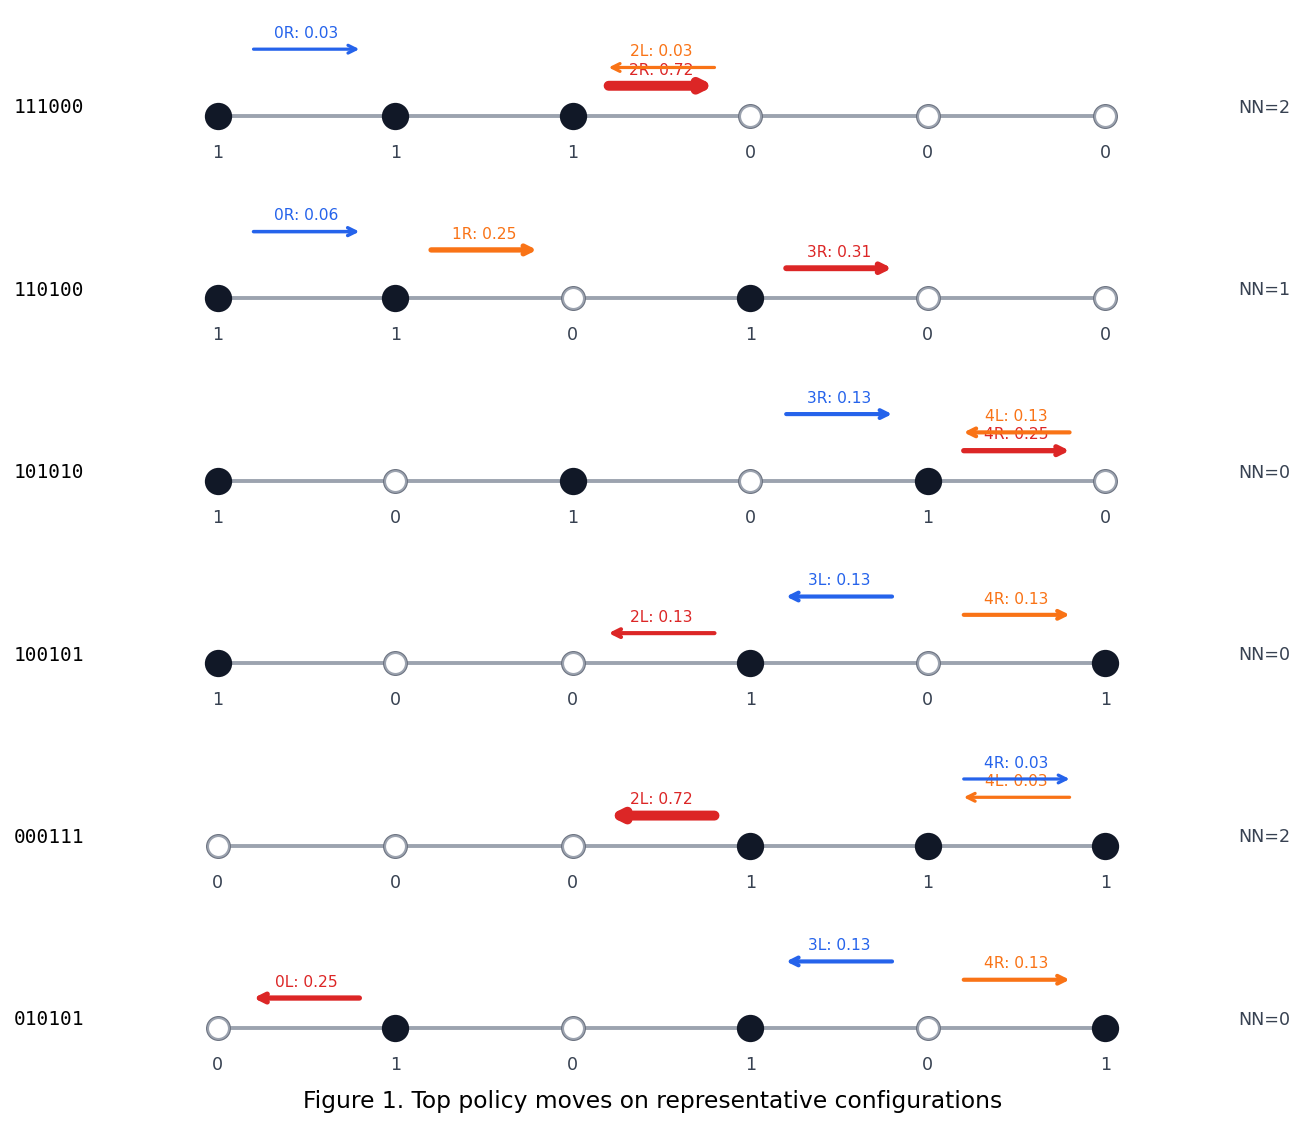

In [4]:
draw_policy_arrows(chain, pi_exact)

**图 1 说明。**  

这张图直接显示“策略想怎么移动粒子”。  
例如 `111000` 中三个粒子挤在左侧，最近邻占据数很高。由于 $V>0$ 惩罚相邻占据，红色箭头倾向于把右边界粒子向右移动，从而把团簇拉开。  
较分散的构型中，多个动作的价值接近，因此箭头概率更分散。

In [5]:
rows = []
for s_idx, state in enumerate(chain.states):
    best = int(np.argmax(pi_exact[s_idx]))
    nn = sum(state[i] * state[i+1] for i in range(params.L - 1))
    rows.append((state_labels[s_idx], nn, action_labels[best], pi_exact[s_idx, best]))

print(f"{'state':>8}  {'NN pairs':>8}  {'best action':>12}  {'prob':>8}")
for state, nn, action, prob in rows:
    print(f"{state:>8}  {nn:8d}  {action:>12}  {prob:8.4f}")

   state  NN pairs   best action      prob
  111000         2     bond 2, R    0.7222
  110100         1     bond 3, R    0.3067
  110010         1     bond 1, R    0.4347
  110001         1     bond 1, R    0.4673
  101100         1     bond 3, R    0.5348
  101010         0     bond 4, R    0.2450
  101001         0     bond 0, L    0.1252
  100110         1     bond 4, R    0.3584
  100101         0     bond 2, L    0.1252
  100011         1     bond 3, L    0.4673
  011100         2     bond 3, R    0.4243
  011010         1     bond 0, L    0.4148
  011001         1     bond 0, L    0.3584
  010110         1     bond 4, R    0.4148
  010101         0     bond 0, L    0.2450
  010011         1     bond 3, L    0.4347
  001110         2     bond 1, L    0.4243
  001101         1     bond 1, L    0.5348
  001011         1     bond 1, L    0.3067
  000111         2     bond 2, L    0.7222


## 4. 图 2：policy 熵与拥挤程度

最近邻占据数定义为

$$
C(n)=\sum_{i=1}^{L-1} n_i n_{i+1}.
$$

图 2 横轴是 $C(n)$，纵轴是归一化 policy entropy：

$$
H(n)
=
-\frac{1}{\log\lvert\mathcal{A}\rvert}
\sum_a \pi_\beta^*(a\mid n)\log \pi_\beta^*(a\mid n).
$$

如果 $H(n)$ 接近 1，policy 接近均匀；如果 $H(n)$ 较小，policy 更集中在少数动作上。  
点的颜色表示最大动作概率，颜色越深表示最优动作越占主导。

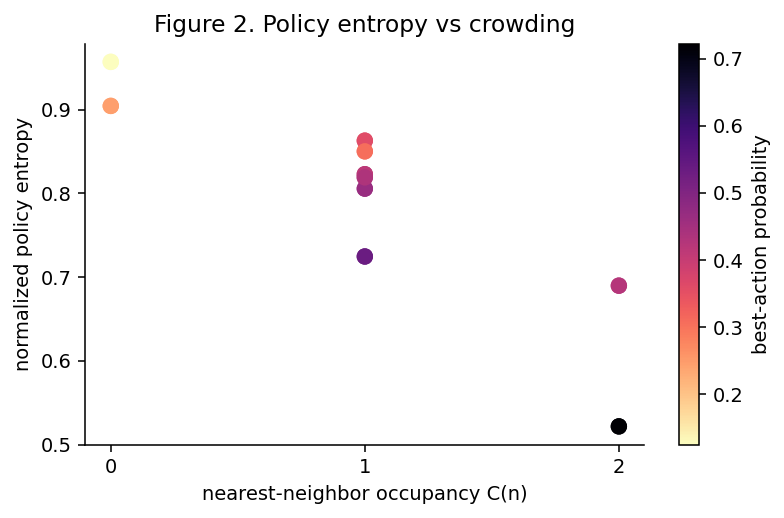

In [6]:
draw_policy_entropy(chain, pi_exact)

**图 2 说明。**  

这个图比 heatmap 更容易看整体趋势。  
拥挤程度高的构型通常有更低的 policy entropy，因为少数动作可以明显降低最近邻惩罚。  
分散构型的动作差异较小，policy 更接近均匀，因此 entropy 更高。

## 5. Tensor construction：从 MDP 到 MPS/MPO 的完整对应

这一节把所有 tensor 结构集中在一起。目标不是只画示意图，而是明确回答：

1. 一个 state-action pair $(n,a)$ 如何变成一条 MPS 输入链；
2. 左右 Perron eigenfunctions $u(n,a)$ 与 $v(n,a)$ 如何写成两套 MPS；
3. tilted operator $K_\beta(n',a'\mid n,a)$ 如何写成 MPO；
4. 代码里的每一步到底对应哪个张量网络对象。

### 5.1 合法 state-action sector 与局域指标

体系长度为 $L$，固定粒子数为 $N$。状态空间是

$$
\mathcal{S}_{L,N}
=
\left\{
n=(n_1,\dots,n_L):
n_j\in\{0,1\},\ 
\sum_{j=1}^L n_j=N
\right\}.
$$

action 是选择一个 bond 和方向：

$$
a=(i,\sigma),
\qquad
i=1,\dots,L-1,
\qquad
\sigma\in\{+,-\}.
$$

为了让 MPS/MPO 看到 action，我们不用一个全局离散标签表示 $a$，而是把它编码成一条局域 marker 字符串

$$
m=(m_1,\dots,m_L),
\qquad
m_j\in\{0,+,-\}.
$$

若 $a=(i,+)$，则

$$
m_i=+,\qquad m_{j\ne i}=0.
$$

若 $a=(i,-)$，则

$$
m_i=-,\qquad m_{j\ne i}=0.
$$

因此合法 action-marker sector 满足

$$
\sum_{j=1}^{L-1}\mathbf{1}_{m_j\ne 0}=1,
\qquad
m_L=0.
$$

每个 site 的 physical index 是

$$
y_j=(n_j,m_j).
$$

因为 $n_j\in\{0,1\}$ 且 $m_j\in\{0,+,-\}$，所以局域维数是

$$
d_{\rm loc}=2\times 3=6.
$$

代码中用整数

$$
y_j = 3 n_j + {\rm marker}(m_j),
\qquad
{\rm marker}(0)=0,\ {\rm marker}(+)=1,\ {\rm marker}(-)=2
$$

编码这个局域指标。这对应 `marker_features`。

In [7]:
state_id = 0
action_id = 4
print("state:", chain.states[state_id])
print("action:", chain.actions[action_id])
print("encoded y-chain:", chain.marker_features(state_id, action_id))

state: (1, 1, 1, 0, 0, 0)
action: (2, 1)
encoded y-chain: [3, 3, 4, 0, 0, 0]


### 5.2 用 MPS 表示左右 Perron eigenfunction

普通 MPS 适合表示一个构型函数

$$
F(n_1,\dots,n_L).
$$

但这里 Perron eigenfunction 是 state-action 函数。对于非厄米 tilted operator，需要区分右 continuation eigenfunction 和左 Perron weight：

$$
u(n,a),
\qquad
v(n,a),
\qquad a=(i,\sigma).
$$

二者使用同一个局域输入链 $y_j=(n_j,m_j)$，但用两套独立 MPS 参数表示。右矢先用 MPS 表示一个无约束实函数
$f_\theta(n,a)$：

$$
f_\theta(n,a)
=
\sum_{\alpha_1,\dots,\alpha_{L-1}}
A^{[1]}_{1,y_1,\alpha_1}
A^{[2]}_{\alpha_1,y_2,\alpha_2}
\cdots
A^{[L]}_{\alpha_{L-1},y_L,1}.
$$

这里 $\alpha_j=1,\dots,\chi$ 是 MPS bond index，边界虚拟指标固定为 1。然后令

$$
u_\theta(n,a)=\exp f_\theta(n,a).
$$

左矢完全平行地表示为

$$
g_\phi(n,a)
=
\sum_{\alpha_1,\dots,\alpha_{L-1}}
B^{[1]}_{1,y_1,\alpha_1}
B^{[2]}_{\alpha_1,y_2,\alpha_2}
\cdots
B^{[L]}_{\alpha_{L-1},y_L,1},
$$

并令

$$
v_\phi(n,a)=\exp g_\phi(n,a).
$$

这样做有两个好处：

- $u_\theta(n,a)$ 与 $v_\phi(n,a)$ 自动为正，符合 Perron-Frobenius 左右本征函数的结构。
- MPS 只需要表示 $f_\theta$ 和 $g_\phi$，数值上比直接强制正函数更稳定。
- $u$ 的整体尺度不影响 Doob policy；$v$ 的整体尺度也只影响 $v u$ 的归一化。因此代码用 `positive_u_from_f` 对每个 MPS 输出减均值作为数值 gauge。
- 学到 $v$ 后，可以直接构造 Doob 稳态分布 $\mu^*(n,a)\propto v_\phi(n,a)u_\theta(n,a)$，这一步是单独学习 $u$ 时没有的。

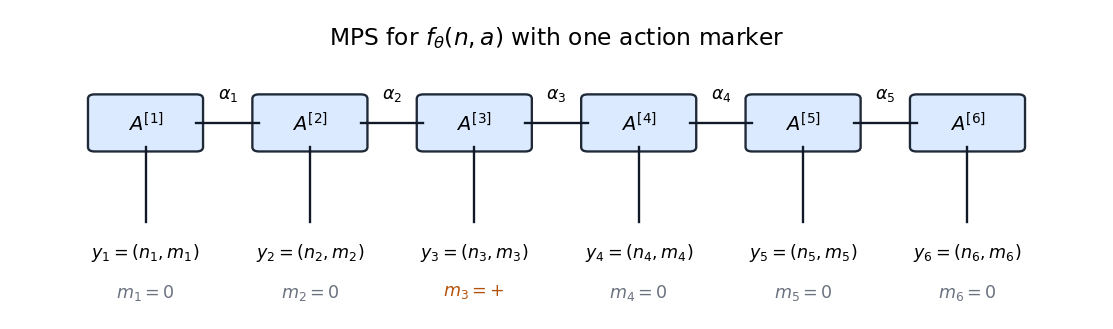

In [8]:
draw_mps_diagram(L=6, active_bond=2, direction="R")

**图 3 说明。**  
这张图画的是右矢 $f_\theta(n,a)$ 的 MPS。左矢 $g_\phi(n,a)$ 使用完全相同的 physical index
$y_j=(n_j,m_j)$ 和相同的 open-boundary MPS 结构，只是参数张量从 $A^{[j]}$ 换成另一套独立的
$B^{[j]}$。橙色标出的 $m_j=+$ 是 action marker，表示当前 action 作用在对应 bond 上并尝试右移。

In [9]:
from controlled_chain_experiment import MPSFunction, positive_u_from_f

u_model_demo = MPSFunction(L=6, local_dim=6, bond_dim=4)
v_model_demo = MPSFunction(L=6, local_dim=6, bond_dim=4)
features_demo = chain.all_feature_tensor()[:3]
f_demo = u_model_demo(features_demo)
g_demo = v_model_demo(features_demo)
u_demo = positive_u_from_f(f_demo)
v_demo = positive_u_from_f(g_demo)

print("features shape:", tuple(features_demo.shape))
print("f_theta shape:", tuple(f_demo.shape))
print("g_phi shape:", tuple(g_demo.shape))
print("u_theta is positive:", bool((u_demo > 0).all()))
print("v_phi is positive:", bool((v_demo > 0).all()))
print("first three feature rows:")
print(features_demo.numpy())

features shape: (3, 6)
f_theta shape: (3,)
g_phi shape: (3,)
u_theta is positive: True
v_phi is positive: True
first three feature rows:
[[4 3 3 0 0 0]
 [5 3 3 0 0 0]
 [3 4 3 0 0 0]]


### 5.3 用 MPO 表示 tilted state-action operator

Perron 方程中的 operator 是

$$
K_\beta(n',a'\mid n,a)
=
p(n'\mid n,a)\,
\pi_0(a'\mid n')\,
\exp[\beta r(n,a,n')].
$$

一个 MPO 表示一个局域算符

$$
K_\beta(y_1',\dots,y_L' \mid y_1,\dots,y_L).
$$

它的张量网络形式是

$$
K_\beta(y'\mid y)
=
\sum_{\gamma_1,\dots,\gamma_{L-1}}
W^{[1]}_{1,\gamma_1}(y_1',y_1)
W^{[2]}_{\gamma_1,\gamma_2}(y_2',y_2)
\cdots
W^{[L]}_{\gamma_{L-1},1}(y_L',y_L).
$$

这里：

- $y_j=(n_j,m_j)$ 是输入 physical index；
- $y_j'=(n_j',m_j')$ 是输出 physical index；
- $\gamma_j$ 是 MPO virtual index。

MPO 的 virtual index 记录有限状态自动机的信息，例如：是否已经看到输入 action marker、是否正在 active bond 上执行 gate、是否已经生成输出 action marker。

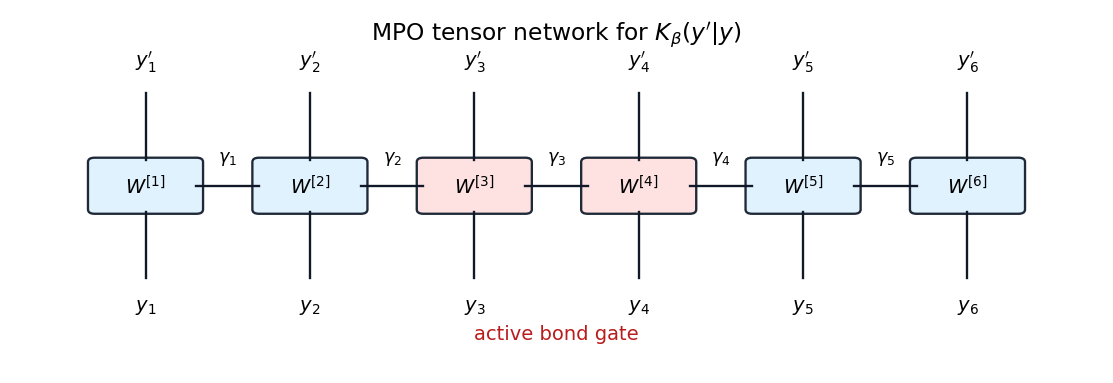

In [10]:
draw_mpo_diagram(L=6, active_bond=2)

**图 4 说明。**  
上图是 $K_\beta(y'\mid y)$ 的 MPO 示意图。  
每个方块 $W^{[j]}$ 有两个物理腿：下方输入 $y_j$，上方输出 $y_j'$。  
相邻方块之间的横线是 MPO 虚拟指标 $\gamma_j$。  
红色位置表示 active bond 附近的局域移动 gate；其它位置主要传递自动机状态和局域 reward 信息。

### 5.4 MPO 自动机具体记录什么

这个 MPO 可以理解成一个从左到右扫描的有限状态自动机。扫描到第 $j$ 个 site 时，它读取输入/输出局域指标

$$
y_j=(n_j,m_j),
\qquad
y_j'=(n_j',m_j').
$$

虚拟指标 $\gamma_j$ 至少需要记录四类信息：

1. **输入 marker 状态**：还没看到 $m_i\ne0$、正在处理 active bond、或已经处理完 active bond。
2. **active-bond payload**：如果刚看到 $m_i=\sigma$，需要把左 site 的信息暂存到下一步，以检查 bond $(i,i+1)$ 的两点 transition。
3. **输出 marker 计数**：确保 $m'_j$ 中恰好有一个非零 marker，从而表示下一步 action $a'$。
4. **最近邻 reward 记忆**：保存前一个输出 occupation $n'_{j-1}$，用来在当前 site 乘上
   $\exp[-\beta V n'_{j-1}n'_j]$。

也就是说，MPO 的 virtual state 可以抽象写成

$$
\gamma_j
=
\bigl(
{\rm phase},\ 
{\rm output\ marker\ seen},\
n'_j,\
{\rm pending\ active\ gate\ data}
\bigr).
$$

这些变量的取值数都不随 $L$ 增长，所以 MPO bond dimension 是 $O(1)$。

更具体地，MPO 在每个 site 做以下检查和乘权重：

1. 在看到输入 marker 之前，若 $m_j=0$，则要求 $n'_j=n_j$，因为 active bond 还没到。
2. 若看到 $m_j=\sigma$，则进入 pending 状态，把左 site 的 $(n_j,n'_j,\sigma)$ 暂存起来。
3. 在下一个 site 检查两点 transition 是否等于尝试移动、失败不动、或非法动作不动。
4. 在 active bond 完成时乘上

$$
{\rm prob}\times \exp[\beta(\lambda J-c_\sigma)].
$$

5. 每经过一个相邻输出 pair，就乘上最近邻 reward 权重

$$
\exp[-\beta V n'_{j-1}n'_j].
$$

6. 扫描结束时只接受“输入 marker 已处理完、输出 marker 恰好出现一次”的路径，并额外乘上 uniform prior

$$
\pi_0(a'\mid n')=\frac{1}{2(L-1)}.
$$

因此它实现的正是分解

$$
K_\beta=\Pi_0\,\mathcal{D}_\Phi\,\widehat{\mathcal{T}},
$$

但在代码里不是把三块分开存，而是合并成一个有限状态自动机 contraction。

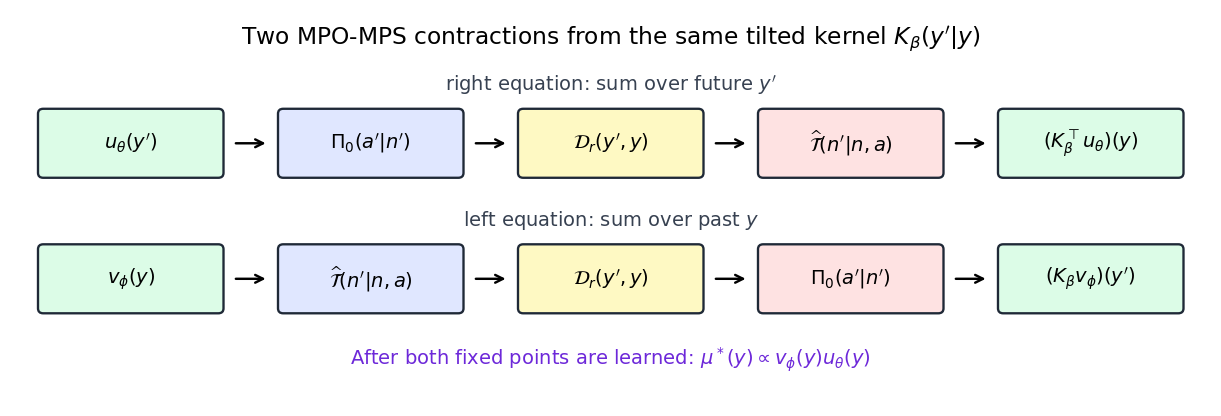

In [11]:
draw_factor_workflow()

**图 5 说明。**  
图 5 展示的是同一个 tilted kernel 的两种 contraction。右矢方程把 $u_\theta(y')$ 放在输出端并对未来
$y'$ 求和，得到 $(K_\beta^\top u_\theta)(y)$；左矢方程把 $v_\phi(y)$ 放在输入端并对过去 $y$ 求和，得到
$(K_\beta v_\phi)(y')$。实际代码中的 `ExplicitTiltedMPO` 把 prior、reward 和受控移动规则合并进一个自动机 MPO；
`train_model_based` 用同一个 restricted MPO matrix 同时计算这两条 contraction。

### 5.5 MPO-MPS contraction 的数学 workflow

有了 MPS 和 MPO，model-based Perron 方程分成右、左两条。右矢 $u$ 是 future continuation weight：

$$
\sum_{y'}
K_\beta^{\rm MPO}(y'\mid y)
u_\theta^{\rm MPS}(y')
=
\rho_{u,\theta} u_\theta^{\rm MPS}(y).
$$

左矢 $v$ 是 past / stationary weight：

$$
\sum_y
K_\beta^{\rm MPO}(y'\mid y)
v_\phi^{\rm MPS}(y)
=
\rho_{v,\phi} v_\phi^{\rm MPS}(y').
$$

在精确 Perron 极限下，二者的本征值应相同：

$$
\rho_{u,\theta}\simeq \rho_{v,\phi}\simeq \rho_\beta.
$$

如果做真正的大体系算法，标准 tensor-network workflow 是：

1. 右矢更新：用 MPO 的输出腿 contraction 作用在 $u_\theta(y')$ 上，得到 $K_\beta^\top u_\theta$；
2. 左矢更新：用同一个 MPO 的输入腿 contraction 作用在 $v_\phi(y)$ 上，得到 $K_\beta v_\phi$；
3. 对两个新 MPS 分别做压缩或 variational fit，把 bond dimension 截回 $\chi$；
4. 用 power iteration、Arnoldi-DMRG、VUMPS-like fixed point 或 residual minimization 同时求左右 fixed points；
5. 用 $\mu^*(y)\propto v_\phi(y)u_\theta(y)$ 计算 conditioned steady-state observables。

当前小体系代码为了便于严格验证，先把显式 MPO contraction 限制到合法 fixed-$N$ state-action sector 上，生成
$200\times200$ 的 restricted matrix；随后用 `K_operator.T @ u` 计算右矢方程，用 `K_operator @ v` 计算左矢方程。
这仍然不是无限链算法，但已经不是 `apply_K_values` 的手写 Bellman 规则，而是显式 MPO entry contraction 后的 restricted-sector 验证。

In [12]:
K_dense = chain.build_exact_K()
K_mpo = ExplicitTiltedMPO(chain).build_restricted_matrix()
diff = K_mpo - K_dense

print("restricted operator shape:", K_mpo.shape)
print("max |K_mpo - K_dense|:", np.max(np.abs(diff)))
print("relative Frobenius error:", np.linalg.norm(diff) / np.linalg.norm(K_dense))

restricted operator shape: (200, 200)
max |K_mpo - K_dense|: 1.3877787807814457e-17
relative Frobenius error: 7.454876021851626e-17


### 5.6 代码 workflow 对照

下面把数学对象、tensor-network 对象和代码对象逐项对应。这里不用 Markdown 表格，是为了避免表格解析器把条件概率中的竖线误认为列分隔符。

**State.**  
数学对象是 occupation string

$$
n=(n_1,\dots,n_L).
$$

它在代码中是 `chain.states`。

**Action.**  
数学对象是 bond-direction pair

$$
a=(i,\sigma).
$$

它在代码中是 `chain.actions`。

**Local physical index.**  
MPS 和 MPO 共用同一个局域指标

$$
y_j=(n_j,m_j).
$$

它在代码中由 `marker_features` 生成。

**Right-MPS eigenfunction ansatz.**  
第一套 MPS 表示右 Perron 矢的 log-amplitude

$$
f_\theta(n,a),
$$

对应 `u_model = MPSFunction(...)` 和 `u_model.forward`。正右 Perron 函数取为

$$
u_\theta(n,a)=\exp f_\theta(n,a),
$$

对应 `positive_u_from_f`。

**Left-MPS eigenfunction ansatz.**  
第二套 MPS 表示左 Perron 矢的 log-amplitude

$$
g_\phi(n,a),
$$

对应 `v_model = MPSFunction(...)` 和 `v_model.forward`。正左 Perron weight 取为

$$
v_\phi(n,a)=\exp g_\phi(n,a).
$$

代码复用同一个 `MPSFunction` 类；区别只在于 `u_model` 和 `v_model` 是两套独立参数。

**Local transition gate.**  
active bond 的 transition kernel 是

$$
p(n'\mid n,a).
$$

它在自动机 MPO 中由 `ExplicitTiltedMPO._finish_pending` 检查并给出局域概率。

**Tilted reward weight.**  
MPO 在扫描时乘上

$$
\exp[\beta r(n,a,n')].
$$

其中最近邻势能来自输出 occupation 的相邻 pair，active-bond current 和 cost 在完成 active gate 时乘入。代码入口是 `ExplicitTiltedMPO.entry`。

**Next-action prior.**  
输出 marker 字符串表示下一步 action $a'$。自动机只接受恰好一个非零输出 marker，并乘上

$$
\pi_0(a'\mid n')=\frac{1}{\lvert\mathcal{A}\rvert}.
$$

这同样在 `ExplicitTiltedMPO.entry` 中完成。

**Tilted MPO.**  
完整一步 operator 是

$$
K_\beta(y'\mid y).
$$

它由 `ExplicitTiltedMPO.build_restricted_matrix` 在合法 fixed-$N$ sector 上逐元素 contraction 得到。

**Model-based right solve.**  
右矢训练目标对应

$$
K_\beta^\top u_\theta \approx \rho_{u,\theta} u_\theta.
$$

代码中是 `Ku = K_operator.T @ u.reshape(-1)`，然后最小化右 log-residual。

**Model-based left solve.**  
左矢训练目标对应

$$
K_\beta v_\phi \approx \rho_{v,\phi} v_\phi.
$$

代码中是 `Kv = K_operator @ v.reshape(-1)`，然后最小化左 log-residual。`rho_right` 和 `rho_left` 分开训练，最后检查

$$
\frac{\lvert\rho_{u,\theta}-\rho_{v,\phi}\rvert}
{(\rho_{u,\theta}+\rho_{v,\phi})/2}
$$

是否足够小。

**Doob stationary measure.**  
左右矢都得到后，conditioned process 的 state-action 稳态分布是

$$
\mu_{\theta,\phi}^*(y)
=
\frac{v_\phi(y)u_\theta(y)}{\sum_{\tilde y}v_\phi(\tilde y)u_\theta(\tilde y)}.
$$

代码中由 `normalized_positive_product(v_np, u_np)` 得到；随后 `biorthogonal_observables` 用这个分布计算最近邻占据密度和电流密度等观测量。

这一节的关键结论是：MPS 和 MPO 的 physical index 是同一个 $y_j=(n_j,m_j)$。MPS 给出
$u_\theta(y)$ 与 $v_\phi(y)$，MPO 给出 $K_\beta(y'\mid y)$，二者通过

$$
(K_\beta^\top u_\theta)(y)=\sum_{y'}K_\beta(y'\mid y)u_\theta(y')
$$

以及

$$
(K_\beta v_\phi)(y')=\sum_y K_\beta(y'\mid y)v_\phi(y)
$$

连接到左右 Perron 方程。

## 6. 三步数值 workflow

### Step 1：精确解

显式构造 $200\times200$ 的矩阵 $K$，求解

$$
K^\top u=\rho u.
$$

### Step 2：显式 MPO + 双 MPS model-based

用两个 MPS 表示左右 Perron 矢：

$$
u_\theta(n,a)=\exp f_\theta(n,a),
\qquad
v_\phi(n,a)=\exp g_\phi(n,a).
$$

因为模型规则已知，可以把 $K_\beta$ 写成有限状态自动机 MPO。它逐站点扫描 $y_j=(n_j,m_j)$ 和
$y_j'=(n_j',m_j')$，在虚拟指标中记录 input marker、active-bond gate、output marker 和最近邻 reward 的短程记忆。右矢方程对每个 $(n,a)$ 计算

$$
(K u_\theta)(n,a)
=
\sum_{n',a'}K(n',a'\mid n,a)u_\theta(n',a').
$$

左矢方程对应

$$
(K v_\phi)(n',a')
=
\sum_{n,a}K(n',a'\mid n,a)v_\phi(n,a).
$$

训练目标是左右两个 log-Perron residual：

$$
\mathcal{L}_{\rm model}
=
\left\langle
\left[
\log (K u_\theta)(n,a)
-\log\rho_{u,\theta}
-\log u_\theta(n,a)
\right]^2
\right\rangle_{n,a}
+
\left\langle
\left[
\log (K v_\phi)(n,a)
-\log\rho_{v,\phi}
-\log v_\phi(n,a)
\right]^2
\right\rangle_{n,a}.
$$

训练后检查 $\rho_{u,\theta}$ 与 $\rho_{v,\phi}$ 是否一致，并用

$$
\mu_{\theta,\phi}^*(n,a)
\propto
v_\phi(n,a)u_\theta(n,a)
$$

和精确 Doob 稳态分布比较。

### Step 3：sampled $u$-$\theta$ learning

不显式求和，而是采样

$$
(n_t,a_t,r_t,n_{t+1},a_{t+1})
$$

并使用 TD residual：

$$
\delta_t
=
e^{\beta r_t}u_\theta(n_{t+1},a_{t+1})
-\rho_\theta u_\theta(n_t,a_t).
$$

实际训练中对 target 端停止梯度，并用 batch ratio 辅助更新 $\rho_\theta$。这比直接压单样本 Bellman residual 稳定。

## 7. 与 Arriojas 文章源码的对照

我检查了 W003 上 `~/thermodynamic_limit_entropy_RL` 中的原文源码。结论是：model-based 部分与原文完全同构；sampled MPS 部分是合理的函数逼近原型，但不是原文 tabular update 的逐字等价形式。

### 7.1 Model-based Perron 解法

原文 `utils.py` 的核心步骤是先构造

$$
M=P T,
$$

其中

$$
T_{z,z}=\exp[\beta r(z)].
$$

然后对

$$
M^\top u=\rho u
$$

做 power iteration。得到 $u$ 后，用

$$
\pi^*(a\mid s)\propto \pi_0(a\mid s)u(s,a)
$$

重构 policy。

本 notebook 的 exact / model-based MPS 做的是同一个 Perron 问题。区别只是：

- 原文显式存储 tabular $u(s,a)$；
- 这里用 action-marker MPS 表示 $u_\theta(n,a)$，并额外用第二套 MPS 表示左矢 $v_\phi(n,a)$；
- 原文显式构造 sparse matrix；
- 这里用 `ExplicitTiltedMPO` 的有限状态自动机 contraction 实现同一个 tilted operator。

所以，**model-based MPS 是合理的**：它把原文的 tabular Perron eigenvector 换成 MPS ansatz；新版进一步把原文中用于归一化、稳态权重和 bulk observable 的左 Perron vector 也显式 MPS 化。

### 7.2 Model-free $u$-$\theta$ learning

原文 tabular update 是

$$
u(s,a)
\leftarrow
(1-\alpha)u(s,a)
+
\alpha
\frac{\exp[\beta r]}{\rho}
u(s',a'),
$$

以及

$$
\rho
\leftarrow
(1-\alpha_\rho)\rho
+
\alpha_\rho
\exp[\beta r]
\frac{u(s',a')}{u(s,a)}.
$$

这里的样本 $(s,a,r,s',a')$ 来自 prior policy 和环境 transition。

我们的 MPS sampled 版本不能只更新单个表格元素，因为所有 $u_\theta(n,a)$ 共享同一组 MPS 参数。因此我们改成 TD-style 函数逼近：

$$
\delta_t
=
e^{\beta r_t}u_\theta(n_{t+1},a_{t+1})
-
\rho_\theta u_\theta(n_t,a_t).
$$

训练时对 target 端停止梯度，并用 batch ratio 辅助更新 $\rho_\theta$。这不是原文算法的严格等价形式，而是它的函数逼近版本。

因此，**sampled MPS $u$-$\theta$ learning 目前应理解为 prototype**。它能学到正确方向，但稳定性比 model-based 差。更严谨的下一版需要 target network、replay buffer、明确的 gauge normalization；若要从采样中直接估计 Doob 稳态，还需要采样版左矢/occupancy-ratio 学习，而不仅是右矢 TD。

## 8. 读取或重新生成三步结果

默认读取已有结果。如果要重新跑训练，把 `RUN_TRAINING` 改为 `True`。  
完整重跑大约需要数分钟。

In [13]:
RUN_TRAINING = False

if RUN_TRAINING:
    cmd = [
        "/opt/miniconda3/envs/myenv1/bin/python", "controlled_chain_experiment.py",
        "--L", "6", "--N", "3",
        "--bond-dim", "16",
        "--model-steps", "4000",
        "--sample-steps", "1000",
        "--batch-size", "256",
        "--lr", "0.002",
        "--out", str(RESULT_PATH),
    ]
    subprocess.run(cmd, check=True)

with open(RESULT_PATH) as f:
    result = json.load(f)

mpo_check = result.get("step2a_explicit_mpo_validation", {})
print("Explicit MPO validation")
print("max abs entry error:", mpo_check.get("max_abs_entry_error"))
print("relative Frobenius error:", mpo_check.get("frobenius_relative_error"))

Explicit MPO validation
max abs entry error: 1.3877787807814457e-17
relative Frobenius error: 7.454876021851627e-17


In [14]:
summary = [
    {
        "method": "Exact",
        "rho": result["step1_exact"]["rho"],
        "rho_err": 0.0,
        "right_res": result["step1_exact"]["right_relative_residual"],
        "left_res": result["step1_exact"]["left_relative_residual"],
        "u_cos": 1.0,
        "v_cos": 1.0,
        "mu_cos": 1.0,
    },
    {
        "method": "MPS model-based",
        "rho": result["step2_mps_model_based"]["rho"],
        "rho_err": result["step2_mps_model_based"]["rho_rel_error"],
        "right_res": result["step2_mps_model_based"]["right_relative_residual"],
        "left_res": result["step2_mps_model_based"]["left_relative_residual"],
        "u_cos": result["step2_mps_model_based"]["u_cosine_with_exact"],
        "v_cos": result["step2_mps_model_based"]["v_cosine_with_exact"],
        "mu_cos": result["step2_mps_model_based"]["doob_stationary_cosine_with_exact"],
    },
    {
        "method": "Sampled u-theta",
        "rho": result["step3_mps_sampled_u_theta"]["rho"],
        "rho_err": result["step3_mps_sampled_u_theta"]["rho_rel_error"],
        "right_res": result["step3_mps_sampled_u_theta"]["relative_residual"],
        "left_res": np.nan,
        "u_cos": result["step3_mps_sampled_u_theta"]["u_cosine_with_exact"],
        "v_cos": np.nan,
        "mu_cos": np.nan,
    },
]

print(f"{'method':<18} {'rho':>12} {'rho err':>10} {'right res':>10} {'left res':>10} {'u cos':>9} {'v cos':>9} {'mu cos':>9}")
for row in summary:
    print(
        f"{row['method']:<18} {row['rho']:12.8f} {row['rho_err']:10.3e} "
        f"{row['right_res']:10.3e} {row['left_res']:10.3e} "
        f"{row['u_cos']:9.6f} {row['v_cos']:9.6f} {row['mu_cos']:9.6f}"
    )

model_metrics = result["step2_mps_model_based"]
exact_obs = result["step1_exact"]["doob_stationary_observables"]
model_obs = model_metrics["doob_stationary_observables"]
print("\nLeft/right model-based diagnostics")
print("rho_right:", model_metrics["rho_right"])
print("rho_left:", model_metrics["rho_left"])
print("rho left/right relative mismatch:", model_metrics["rho_left_right_rel_mismatch"])
print("Doob stationary L1 error:", model_metrics["doob_stationary_l1_error"])
print("Exact stationary observables:", exact_obs)
print("MPS stationary observables:", model_obs)

method                      rho    rho err  right res   left res     u cos     v cos    mu cos
Exact                0.77522215  0.000e+00  1.782e-15  1.779e-15  1.000000  1.000000  1.000000
MPS model-based      0.77479417  5.521e-04  5.147e-04  5.518e-04  0.999999  0.999998  0.999998
Sampled u-theta      0.75739049  2.300e-02  7.789e-02        nan  0.990972       nan       nan

Left/right model-based diagnostics
rho_right: 0.7748279380304056
rho_left: 0.774760394451596
rho left/right relative mismatch: 8.717615820130037e-05
Doob stationary L1 error: 0.002391054544558987
Exact stationary observables: {'nn_occupancy_density': 0.015417588829532253, 'prior_expected_current_density': 1.7257197650807309e-16}
MPS stationary observables: {'nn_occupancy_density': 0.015469020649771311, 'prior_expected_current_density': 4.279014073319565e-05}


## 9. 图 6：三种方法的数值比较

图 6 分三栏：

1. Perron eigenvalue $\rho$；
2. 右/左相对本征残差；
3. 与精确 $u$、$v$、以及 $\mu^*\propto vu$ 的归一化内积。

第三栏越接近 1，说明学到的 Perron pair 与 Doob 稳态越接近精确解。

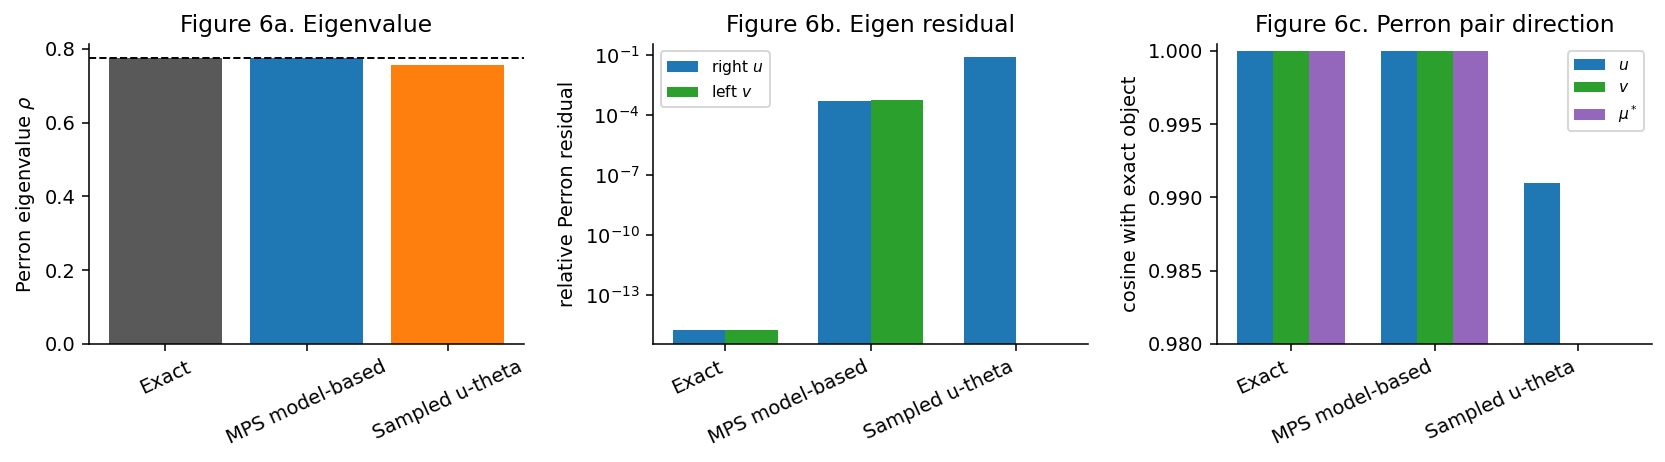

In [15]:
methods = [s["method"] for s in summary]
rho_vals = [s["rho"] for s in summary]
right_resids = [max(s["right_res"], 1e-16) for s in summary]
left_resids = [s["left_res"] for s in summary]
u_cosines = [s["u_cos"] for s in summary]
v_cosines = [s["v_cos"] for s in summary]
mu_cosines = [s["mu_cos"] for s in summary]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))

axes[0].bar(methods, rho_vals, color=["0.35", "tab:blue", "tab:orange"])
axes[0].axhline(rho_exact, ls="--", color="k", lw=1)
axes[0].set_ylabel(r"Perron eigenvalue $\rho$")
axes[0].set_title("Figure 6a. Eigenvalue")
axes[0].tick_params(axis="x", rotation=25)

width = 0.36
x = np.arange(len(methods))
axes[1].bar(x - width/2, right_resids, width=width, label="right $u$", color="tab:blue")
left_plot = [v if np.isfinite(v) else 0.0 for v in left_resids]
axes[1].bar(x + width/2, left_plot, width=width, label="left $v$", color="tab:green")
axes[1].set_yscale("log")
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods, rotation=25, ha="right")
axes[1].set_ylabel("relative Perron residual")
axes[1].set_title("Figure 6b. Eigen residual")
axes[1].legend(fontsize=8)

width = 0.25
axes[2].bar(x - width, u_cosines, width=width, label="$u$", color="tab:blue")
axes[2].bar(x, [v if np.isfinite(v) else 0.0 for v in v_cosines], width=width, label="$v$", color="tab:green")
axes[2].bar(x + width, [m if np.isfinite(m) else 0.0 for m in mu_cosines], width=width, label=r"$\mu^*$", color="tab:purple")
axes[2].set_ylim(0.98, 1.0005)
axes[2].set_xticks(x)
axes[2].set_xticklabels(methods, rotation=25, ha="right")
axes[2].set_ylabel("cosine with exact object")
axes[2].set_title("Figure 6c. Perron pair direction")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

**图 6 说明。**

**(a) Eigenvalue.**  
MPS model-based 的 $\rho$ 与精确值几乎重合；新版还同时报告 $\rho_u$ 与 $\rho_v$，二者 mismatch 约为 $10^{-4}$。sampled $u$-$\theta$ 有可见偏差，因为它只用有限采样估计 Bellman expectation。

**(b) Eigen residual.**  
精确解残差在机器精度；model-based MPS 的右、左残差都在 $10^{-4}$ 到 $10^{-3}$ 量级。sampled 方法只学习右矢 $u$，所以没有左残差。

**(c) Eigenfunction direction.**  
model-based MPS 与精确 $u$、$v$ 的 cosine 都接近 $0.999998$，并且 $\mu^*\propto vu$ 的 cosine 也接近 $0.999998$。这说明 $\chi=16$ 不仅能表达控制用的右矢，也能表达 Doob 稳态所需的左矢。

## 10. 最终结论

这个 notebook 验证了三点：

1. 我们定义的多 agent 最近邻 reward MDP 可以严格写成 state-action Perron 问题。
2. 对小体系，显式对角化给出非平凡最优 policy，说明这个问题确实是控制问题，不是普通随机游走。
3. $K_\beta$ 可以用有限状态自动机 MPO 在合法 sector 上逐元素复现；右矢 $u(n,a)$ 与左矢 $v(n,a)$ 都可以用 action-marker MPS 表示。
4. model-based 双 MPS 同时给出控制 policy 所需的 $u$ 和 Doob 稳态所需的 $\mu^*\propto vu$。
5. sampled MPS $u$-$\theta$ learning 也能学到正确方向，但目前只学习右矢，精度低于 model-based，这正是采样学习与显式 Bellman expectation 的差别。

下一步如果要推进到热力学极限，应优先做有限尺寸序列：

$$
L=6,8,10,\dots,\qquad N/L=\bar\rho.
$$

并画

$$
\frac{1}{L}\log\rho_{\beta,L}
$$

随 $L$ 的收敛。